In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re
from functools import partial

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import LabelEncoder


from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense,BatchNormalization, Dropout, LSTM,RepeatVector, TimeDistributed

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import tensorflow as tf
import seaborn as sns







In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = 100#int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [3]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [4]:
lista_label = df['label'].unique().tolist()

In [5]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [6]:
df_result

,vector_id,execution_name,label
0,90244,light-oauth2-data-1719592986.tar,correct
1,90245,light-oauth2-data-1719592986.tar,correct
2,90246,light-oauth2-data-1719592986.tar,correct
3,90247,light-oauth2-data-1719592986.tar,correct
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400
...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match


In [7]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

lista_limpia = [metrica.split('(')[0] for metrica in lista_metric_name_vector]

# 2. Contar los valores únicos totales
valores_unicos = set(lista_limpia)
N_metric_value = len(valores_unicos)

# <span style="color:#2ca02c">1. Recuperamos separación ya hecha en conjuntos de train, val y test</span>

In [8]:
SQL='select * from vectores_split'
df_split = pd.read_sql(SQL, engine)

In [9]:
df_result = pd.merge(df_result, df_split, on="vector_id", how="inner")

In [10]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,test
1,90245,light-oauth2-data-1719592986.tar,correct,train
2,90246,light-oauth2-data-1719592986.tar,correct,train
3,90247,light-oauth2-data-1719592986.tar,correct,test
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


In [11]:
dic_idx_train = {}
#dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [12]:
for label in lista_label:
    idx_train = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'train') ].index.values
    idx_val   = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'val'  ) ].index.values
    idx_test  = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'test') ].index.values
    dic_idx_train[label] = idx_train
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [13]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

In [14]:
timesteps = 3

X_matrix_LSTM = X_matrix.reshape((X_matrix.shape[0], timesteps, N_metric_value))

In [15]:
X_matrix_LSTM.shape

(90190, 3, 118)

# <span style="color:#2ca02c">2. Preparacion de datos para entrenamiento/test</span>

In [16]:
lista_result=[]

In [17]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [18]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [19]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix_LSTM[idx_test]

In [20]:
X_correct_train = X_matrix_LSTM[idx_correct_train]
X_correct_test  = X_matrix_LSTM[idx_correct_test]

In [21]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

# <span style="color:#2ca02c">3. Detección de anomalías</span>

## <span style="color:#2ca02c">3.1. Optimizacion con optuna</span>

In [55]:


input_shape = (timesteps, N_metric_value)

# 3. Callback de verbose para ver el progreso de Optuna
def print_callback(study, trial):

    p = trial.params
    # Leemos el atributo que guardamos en el trial
    actual_epochs = trial.user_attrs.get('actual_epochs', 'N/D')
    max_epochs = p.get('epochs')
    
    print(f"Trial {trial.number} finalizado | Mejor Loss (MSE): {study.best_value:.6f} | Parámetros: {trial.params} |"
         f"Épocas: {actual_epochs}/{max_epochs} (reales/máx) ")


def create_lstm_autoencoder(units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        # Dropout integrado en la LSTM del Encoder
        LSTM(units, input_shape=input_shape, return_sequences=False, dropout=dropout_rate),
        RepeatVector(input_shape[0]),
        # Dropout integrado en la LSTM del Decoder
        LSTM(units, return_sequences=True, dropout=dropout_rate),
        TimeDistributed(Dense(input_shape[1]))
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model



# 5. Función objetivo de Optuna recibiendo el diccionario externo
def objective_lstm_ae(trial, config):
    units = trial.suggest_categorical('units', config['units'])
    learning_rate = trial.suggest_categorical('learning_rate', config['learning_rate'])
    batch_size = trial.suggest_categorical('batch_size', config['batch_size'])
    epochs = trial.suggest_categorical('epochs', config['epochs'])
    dropout_rate = trial.suggest_categorical('dropout_rate', config['dropout_rate'])
    
    model = create_lstm_autoencoder(
        units=units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        input_shape=input_shape
    )
    
    early_stopping = EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    
    # Entrenamiento exclusivo con datos correctos extraídos de X_matrix_lstm
    history = model.fit(
        X_correct_train, X_correct_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )
    
    #recuperamos el numero de epocas realizadas para mostrarlas en el resultado
    actual_epochs = len(history.history['loss'])
    trial.set_user_attr('actual_epochs', actual_epochs)
    
    return min(history.history['loss'])






In [56]:
# 6. Definición externa de hiperparámetros
params_grid_lstm_ae = {
    'units': [32, 64, 128],
    'dropout_rate': [0.0, 0.1, 0.2, 0.3], # Tasas de dropout a evaluar
    'learning_rate': [0.01, 0.001, 0.0005],
    'batch_size': [32, 64],
    'epochs': [50]
}

# 7. Crear el estudio Optuna (minimize porque buscamos el menor error de reconstrucción MSE)
study_lstm_ae = optuna.create_study(direction='minimize')

# 8. Enlazar la función con los parámetros mediante partial
objective_func_lstm_ae = partial(objective_lstm_ae, config=params_grid_lstm_ae)

# 9. Ejecutar la optimización
print("=== INICIANDO OPTIMIZACIÓN DE LSTM AUTOENCODER ===")
study_lstm_ae.optimize(objective_func_lstm_ae, n_trials=50, callbacks=[print_callback], n_jobs=-1)


[I 2026-07-29 13:55:38,189] A new study created in memory with name: no-name-d4a90595-545c-4d35-85d0-ce88d5232b6b
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== INICIANDO OPTIMIZACIÓN DE LSTM AUTOENCODER ===


[I 2026-07-29 13:58:39,944] Trial 28 finished with value: 0.19019438326358795 and parameters: {'units': 32, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.3}. Best is trial 28 with value: 0.19019438326358795.


Trial 28 finalizado | Mejor Loss (MSE): 0.190194 | Parámetros: {'units': 32, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.3} |Épocas: 22/50 (reales/máx) 


[I 2026-07-29 13:59:02,688] Trial 16 finished with value: 0.17241384088993073 and parameters: {'units': 32, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.2}. Best is trial 16 with value: 0.17241384088993073.


...

Trial 41 finalizado | Mejor Loss (MSE): 0.009651 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.1} |Épocas: 50/50 (reales/máx) 


[I 2026-07-29 14:18:26,584] Trial 43 finished with value: 0.00967651978135109 and parameters: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0}. Best is trial 15 with value: 0.009650837630033493.


Trial 43 finalizado | Mejor Loss (MSE): 0.009651 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


[I 2026-07-29 14:18:29,846] Trial 42 finished with value: 0.009737813845276833 and parameters: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0}. Best is trial 15 with value: 0.009650837630033493.


Trial 42 finalizado | Mejor Loss (MSE): 0.009651 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


In [57]:
study_lstm_ae.best_params

{'units': 128,
 'learning_rate': 0.001,
 'batch_size': 32,
 'epochs': 50,
 'dropout_rate': 0.0}

## <span style="color:#2ca02c">3.2. Entrenamiento profundo del LSTM AE con los hiperparámetros optimizados</span>

In [58]:
lista_result=[]
mejores_params = study_lstm_ae.best_params
# mejores_params = {'units': 128,
#  'learning_rate': 0.001,
#  'batch_size': 32,
#  'epochs': 50,
#  'dropout_rate': 0.0}

In [59]:

print("\n=== MEJOR COMBINACIÓN ENCONTRADA (LSTM AUTOENCODER) ===")
print(mejores_params)
print(f"Mejor Loss (MSE): {study_lstm_ae.best_value:.6f}")


#mejores_params = study_lstm_ae.best_params

lstm_ae_opt = create_lstm_autoencoder(
    units=mejores_params['units'],
    learning_rate=mejores_params['learning_rate'],
    input_shape=input_shape,
    dropout_rate=mejores_params['dropout_rate']
)


early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

mejores_params['epochs']=300


print("\nIniciando entrenamiento del modelo definitivo...")
history_final = lstm_ae_opt.fit(
    X_correct_train, X_correct_train,
    batch_size=mejores_params['batch_size'],
    epochs=mejores_params['epochs'],
    callbacks=[early_stopping_final],
    verbose=1
)


=== MEJOR COMBINACIÓN ENCONTRADA (LSTM AUTOENCODER) ===
{'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0}
Mejor Loss (MSE): 0.009651

Iniciando entrenamiento del modelo definitivo...
Epoch 1/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1837
Epoch 2/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1162
Epoch 3/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0927
Epoch 4/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0776
Epoch 5/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0649
Epoch 6/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0507
Epoch 7/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0419
Epoch 8/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0368
Epoch 9/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0329
Epoch 10/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0297
Epoch 11/300
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0272
Epoch 12/300


In [72]:
# 1. Calculas los errores en el train limpio
reconstructions_train = lstm_ae_opt.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step



Calculando errores de reconstrucción en el conjunto de test...


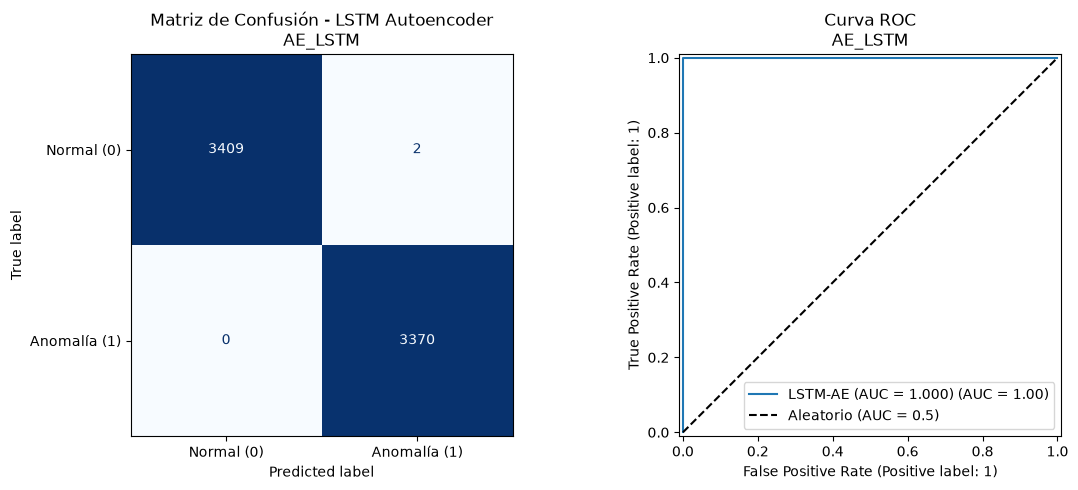

In [73]:


# 1. Calcular los scores (Error de reconstrucción MSE promediando timesteps y features por muestra)
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = lstm_ae_opt.predict(X_test, verbose=0)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=(1, 2))

reconstructions_train = lstm_ae_opt.predict(X_correct_train, verbose=0)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=(1, 2))


# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
y_pred = np.where(scores > threshold, 1, 0)

model_name = 'AE_LSTM'

# 3. Obtener las etiquetas reales (y_true) correctamente desde el DataFrame de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1).values

# Cálculo del AUC-ROC (a mayor error de reconstrucción / score, mayor probabilidad de anomalía)
roc_auc = roc_auc_score(y_true, scores)

# 4. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 5. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = mejores_params.copy() if 'mejores_params' in locals() else {}
parametros['threshold_percentil_scores'] = threshold_percentil_scores

# 6. Guardar en el registro (añadiendo roc_auc)
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}

if 'lista_result' not in locals():
    lista_result = []

lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 7. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica izquierda: Matriz de Confusión
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión - LSTM Autoencoder\n{model_name}')

# Gráfica derecha: Curva ROC
RocCurveDisplay.from_predictions(
    y_true, 
    scores, 
    ax=axes[1], 
    name=f'LSTM-AE (AUC = {roc_auc:.3f})'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [74]:
paquete_autoencoder = {
    'model': lstm_ae_opt,                # El modelo de Keras ya entrenado
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'parametros': mejores_params           # Opcional: guardar los hiperparámetros ganadores
}
joblib.dump(paquete_autoencoder, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/AE_LSTM.joblib']

In [22]:
# paquete_joblib= joblib.load('result/models/AE_LSTM.joblib')

# # 2. Recuperar las variables y el modelo de Keras usando su ruta
# lstm_ae_opt = paquete_joblib['model']

In [23]:
df_anomaly_detection_summary

NameError: name 'df_anomaly_detection_summary' is not defined